Cells after cleaning: 244,504
Total spots: 140
CLR spots: 68, DII spots: 72


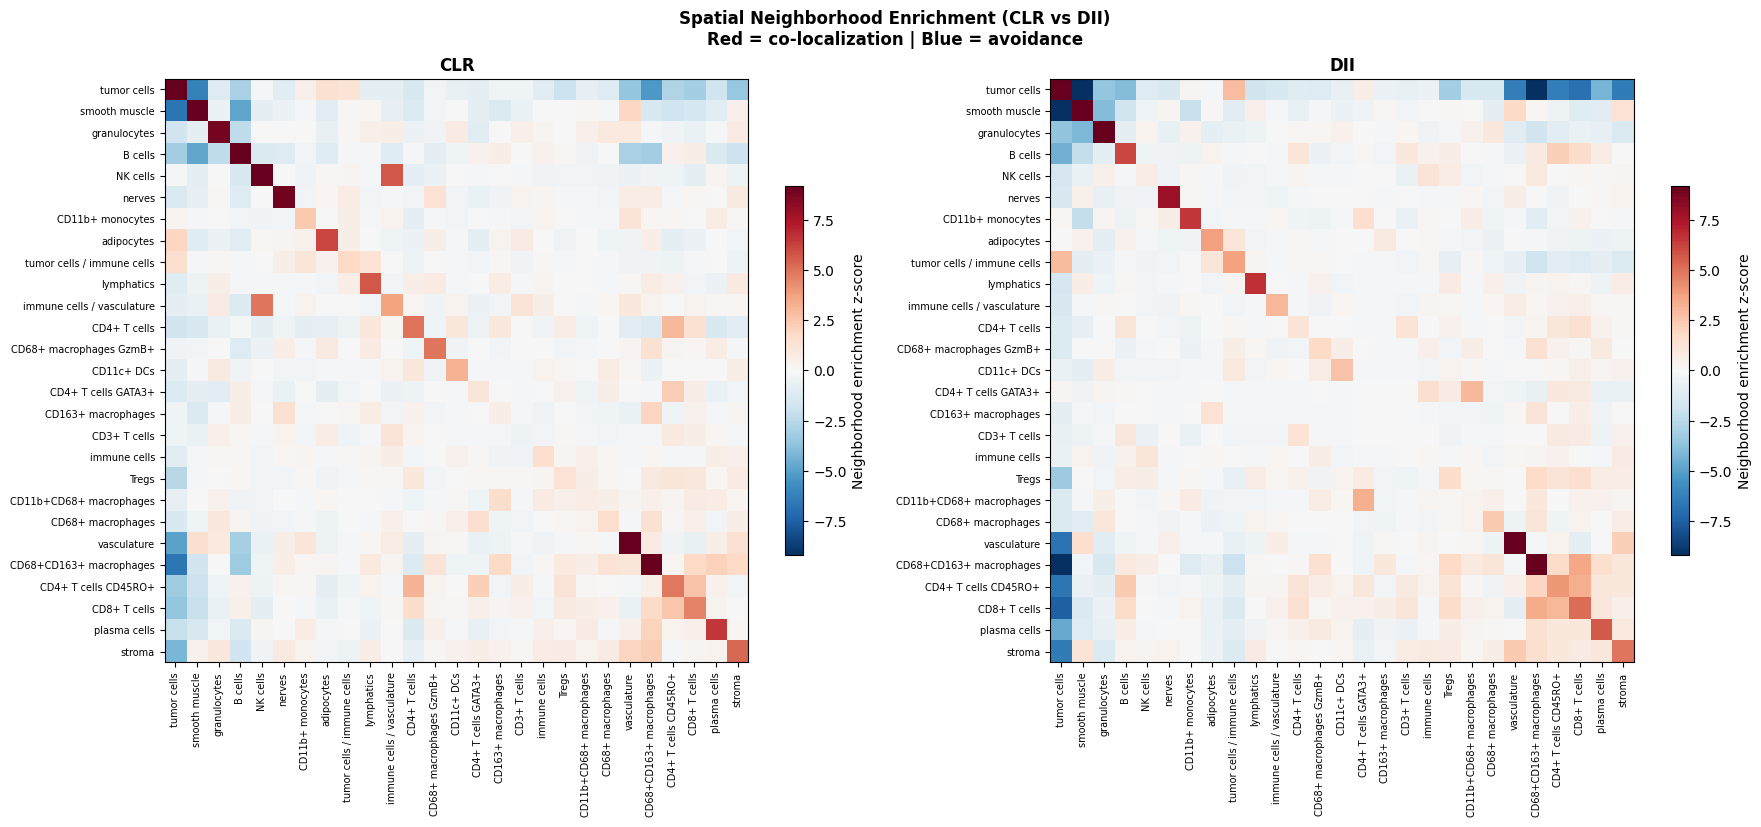

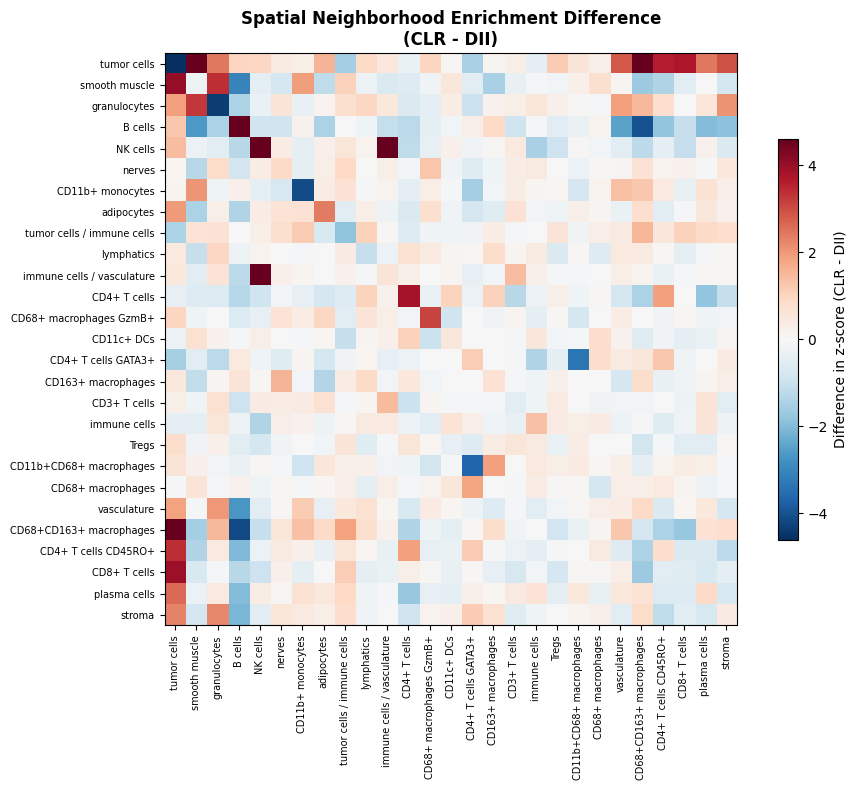

✅ Saved all 3 interaction tables to Supplementary_Table_S2_Spatial_Neighborhood_Enrichment.xlsx


In [1]:
# ==============================
# COMPLETE SQUIDPY PIPELINE
# ==============================

import pandas as pd
import numpy as np
import squidpy as sq
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ==============================
# 1. LOAD & CLEAN DATA
# ==============================
df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")

# Remove unwanted cells
exclude = ['dirt', 'undefined']
df = df[~df['ClusterName'].isin(exclude)].copy()

print(f"Cells after cleaning: {len(df):,}")

# ==============================
# 2. SPOT METADATA
# ==============================
spot_meta = (
    df.drop_duplicates('spots')[['spots', 'groups', 'patients']]
    .set_index('spots')
)

spot_meta['Group'] = spot_meta['groups'].map({1: 'CLR', 2: 'DII'})

print(f"Total spots: {len(spot_meta)}")

# ==============================
# 3. CELL TYPES
# ==============================
cell_types = sorted(df['ClusterName'].unique())

# ==============================
# 4. PARALLEL SQUIDPY PER SPOT 🚀
# ==============================
from joblib import Parallel, delayed
import multiprocessing

n_jobs = multiprocessing.cpu_count() - 2  # use all cores except 1

def process_spot(spot_id):
    sub = df[df['spots'] == spot_id].reset_index(drop=True)
    
    if len(sub) < 30:
        return None
    
    try:
        n = len(sub)
        coords = sub[['X:X', 'Y:Y']].values.astype(float)
        
        obs = pd.DataFrame({
            'cell_type': pd.Categorical(sub['ClusterName'])
        })
        
        adata = ad.AnnData(
            X=sp.eye(n, format='csr'),
            obs=obs,
            obsm={'spatial': coords}
        )
        
        # Spatial neighbors
        sq.gr.spatial_neighbors(
            adata,
            coord_type='generic',
            n_neighs=10
        )
        
        # Neighborhood enrichment
        sq.gr.nhood_enrichment(
            adata,
            cluster_key='cell_type',
            n_perms=1000,
            seed=42
        )
        
        z = adata.uns['cell_type_nhood_enrichment']['zscore']
        cats = adata.obs['cell_type'].cat.categories.tolist()
        z_df = pd.DataFrame(z, index=cats, columns=cats)
        
        grp = spot_meta.loc[spot_id, 'Group']
        
        n_cells = len(sub)
        return (grp, z_df, n_cells)
    
    except Exception as e:
        print(f"Error in spot {spot_id}: {e}")
        return None


# Run in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(process_spot)(spot_id)
    for spot_id in spot_meta.index
)

# Collect results
clr_list = []
dii_list = []

for res in results:
    if res is None:
        continue
    grp, z_df, n_cells = res
    if grp == 'CLR':
        clr_list.append((z_df, n_cells))
    else:
        dii_list.append((z_df, n_cells))

print(f"CLR spots: {len(clr_list)}, DII spots: {len(dii_list)}")
# ==============================
# 5. AGGREGATE MATRICES
# ==============================
def aggregate_stouffer(z_list, all_ct):
    num = pd.DataFrame(0.0, index=all_ct, columns=all_ct)
    denom = pd.DataFrame(0.0, index=all_ct, columns=all_ct)
    
    for z, n in z_list:
        w = np.sqrt(n)  # Stouffer weight
        
        z = z.reindex(index=all_ct, columns=all_ct)
        mask = ~z.isna()
        
        num[mask] += w * z[mask]
        denom[mask] += w
    
    return num / denom.replace(0, np.nan)

clr_agg = aggregate_stouffer(clr_list, cell_types)
dii_agg = aggregate_stouffer(dii_list, cell_types)

# ==============================
# 6. CLEAN INF VALUES
# ==============================
def clean_matrix(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

clr_clean = clean_matrix(clr_agg)
dii_clean = clean_matrix(dii_agg)

# ==============================
# 7. CLUSTER ORDERING
# ==============================
combined = (clr_clean + dii_clean) / 2

dist = pdist(combined.values, metric='euclidean')
link = linkage(dist, method='ward')
order = leaves_list(link)

ordered_ct = [cell_types[i] for i in order]

clr_ord = clr_clean.loc[ordered_ct, ordered_ct]
dii_ord = dii_clean.loc[ordered_ct, ordered_ct]


# ==============================
# 8. PLOT HEATMAPS (SHARED SCALE)
# ==============================

# 🔹 Compute shared scale
all_vals = np.concatenate([
    clr_ord.values.flatten(),
    dii_ord.values.flatten()
])
all_vals = all_vals[~np.isnan(all_vals)]

# vmax = np.max(np.abs(all_vals))
vmax = np.percentile(np.abs(all_vals), 99)
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, data, title in zip(axes, [clr_ord, dii_ord], ['CLR', 'DII']):
    
    vals = data.values
    
    # 🔥 SAME scale for both
    im = ax.imshow(vals, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    
    ax.set_xticks(range(len(ordered_ct)))
    ax.set_yticks(range(len(ordered_ct)))
    ax.set_xticklabels(ordered_ct, rotation=90, fontsize=7)
    ax.set_yticklabels(ordered_ct, fontsize=7)
    
    ax.set_title(title, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label("Neighborhood enrichment z-score")

plt.suptitle(
    "Spatial Neighborhood Enrichment (CLR vs DII)\n"
    "Red = co-localization | Blue = avoidance",
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('CLR_vs_DII_heatmaps_Spatial_Neighborhood_Enrichment.png', dpi=600, bbox_inches='tight')
plt.show()


# ==============================
# DIFFERENCE HEATMAP ONLY (CLR - DII)
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# 🔹 Compute difference
diff_mat = clr_ord - dii_ord

# 🔹 Shared symmetric scale (important)
vals = diff_mat.values

valid_vals = vals[~np.isnan(vals)]
vmax = np.percentile(np.abs(valid_vals), 99)
vmin = -vmax

# 🔹 Plot
plt.figure(figsize=(10, 8))

im = plt.imshow(vals, cmap='RdBu_r', vmin=vmin, vmax=vmax)

# 🔹 Ticks
plt.xticks(range(len(ordered_ct)), ordered_ct, rotation=90, fontsize=7)
plt.yticks(range(len(ordered_ct)), ordered_ct, fontsize=7)

# 🔹 Title
plt.title("Spatial Neighborhood Enrichment Difference\n(CLR - DII)", fontweight='bold')

# 🔹 Colorbar
cbar = plt.colorbar(im, shrink=0.7)
cbar.set_label("Difference in z-score (CLR - DII)")

plt.tight_layout()
plt.savefig('CLR_minus_DII_heatmap_Spatial_Neighborhood_Enrichment.png', dpi=600, bbox_inches='tight')
plt.show()


# ==============================
# EXPORT CLR, DII, AND DIFFERENCE (3 SHEETS)
# ==============================
def matrix_to_long(df, value_name):
    long_df = df.stack().reset_index()
    long_df.columns = ['cell_type_1', 'cell_type_2', value_name]
    
    # Remove symmetric duplicates
    long_df['pair'] = long_df.apply(
        lambda x: tuple(sorted([x['cell_type_1'], x['cell_type_2']])),
        axis=1
    )
    
    long_df = long_df.drop_duplicates('pair')
    
    return long_df.drop(columns='pair')


# ==============================
# CONVERT MATRICES
# ==============================
clr_long = matrix_to_long(clr_ord, 'CLR_zscore')
dii_long = matrix_to_long(dii_ord, 'DII_zscore')
diff_long = matrix_to_long(diff_mat, 'diff_score')


# ==============================
# ADD ABSOLUTE VALUES
# ==============================
clr_long['abs_CLR_zscore'] = clr_long['CLR_zscore'].abs()
dii_long['abs_DII_zscore'] = dii_long['DII_zscore'].abs()
diff_long['abs_diff_score'] = diff_long['diff_score'].abs()


# ==============================
# SORT BASED ON ABSOLUTE VALUES
# ==============================
clr_sorted = clr_long.sort_values('abs_CLR_zscore', ascending=False)
dii_sorted = dii_long.sort_values('abs_DII_zscore', ascending=False)
diff_sorted = diff_long.sort_values('abs_diff_score', ascending=False)


# ==============================
# SAVE TO EXCEL (3 SHEETS)
# ==============================
output_file = "Supplementary_Table_S2_Spatial_Neighborhood_Enrichment.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    clr_sorted.to_excel(writer, sheet_name='CLR_zscores', index=False)
    dii_sorted.to_excel(writer, sheet_name='DII_zscores', index=False)
    diff_sorted.to_excel(writer, sheet_name='CLR_minus_DII', index=False)

print(f"✅ Saved all 3 interaction tables to {output_file}")